<a href="https://colab.research.google.com/github/nishith135/Lane-and-Circular-Object-Detection-using-Hough-Transform-and-RANSAC/blob/main/task3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# UNIT 3 PROJECT: Lane and Circular Object Detection using Hough Transform & RANSAC
# ===============================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import os


In [29]:
print("📤 Please upload a road image (JPG/PNG).")
uploaded = files.upload()

if uploaded:
    image_filename = list(uploaded.keys())[0]
    img = cv2.imread(image_filename)
    print(f"✅ Loaded image: {image_filename}")

📤 Please upload a road image (JPG/PNG).


Saving Luxembourg,_road_marking_(10o_surface_de_lignes_obliques_1).jpg to Luxembourg,_road_marking_(10o_surface_de_lignes_obliques_1).jpg
✅ Loaded image: Luxembourg,_road_marking_(10o_surface_de_lignes_obliques_1).jpg


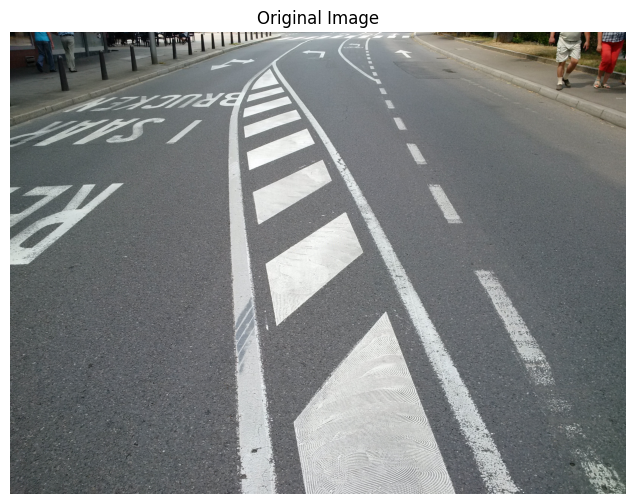

In [30]:

# ======================================================
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10,6))
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()


In [31]:
# Step 2: Preprocessing (Grayscale + Blur)
# ======================================================
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5,5), 0)

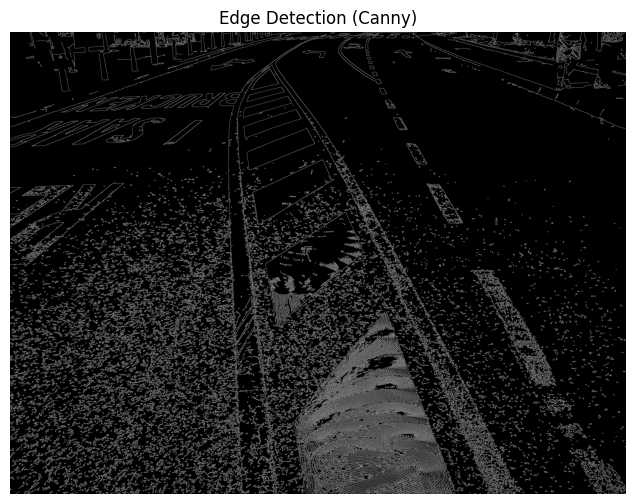

In [32]:
# Step 3: Edge Detection
# ======================================================
edges = cv2.Canny(blur, 50, 150)
plt.figure(figsize=(8,6))
plt.imshow(edges, cmap='gray')
plt.title("Edge Detection (Canny)")
plt.axis("off")
plt.show()

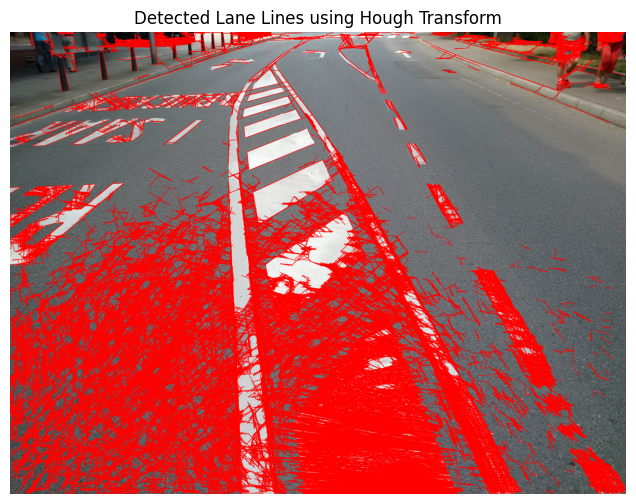

In [33]:

# ======================================================
lines = cv2.HoughLinesP(edges, rho=1, theta=np.pi/180, threshold=50,
                        minLineLength=40, maxLineGap=30)
line_img = img_rgb.copy()

if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(line_img, (x1, y1), (x2, y2), (255, 0, 0), 2)

plt.figure(figsize=(10,6))
plt.imshow(line_img)
plt.title("Detected Lane Lines using Hough Transform")
plt.axis("off")
plt.show()


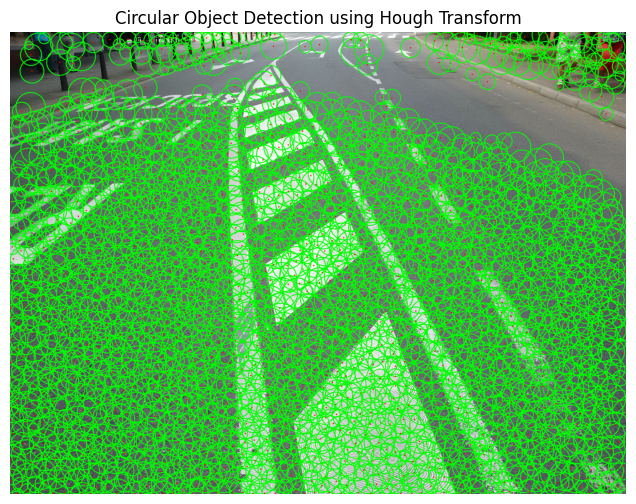

In [34]:
#Step 5: Circle Detection using Hough Transform
# ======================================================
circles = cv2.HoughCircles(gray, cv2.HOUGH_GRADIENT, dp=1.2, minDist=50,
                           param1=100, param2=30, minRadius=20, maxRadius=80)
circle_img = img_rgb.copy()

if circles is not None:
    circles = np.uint16(np.around(circles))
    for c in circles[0, :]:
        cv2.circle(circle_img, (c[0], c[1]), c[2], (0, 255, 0), 3)
        cv2.circle(circle_img, (c[0], c[1]), 2, (255, 0, 0), 3)

plt.figure(figsize=(10,6))
plt.imshow(circle_img)
plt.title("Circular Object Detection using Hough Transform")
plt.axis("off")
plt.show()

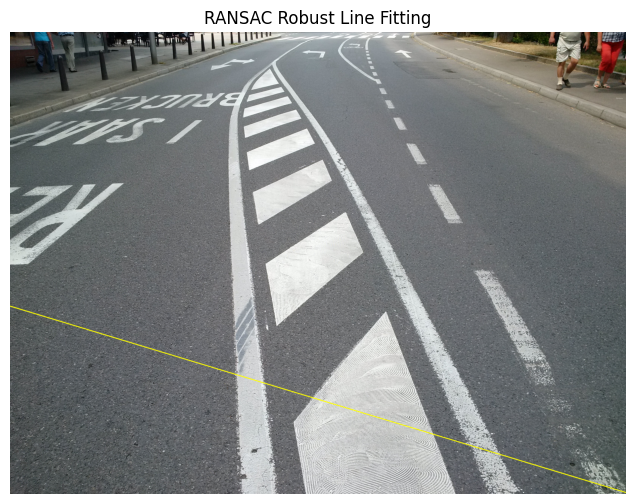

In [35]:
# ======================================================
# Step 6: RANSAC Line Fitting
# ======================================================
def ransac_line_fitting(points, iterations=1000, threshold=3):
    best_line, max_inliers = None, 0
    n_points = len(points)
    for _ in range(iterations):
        sample = points[np.random.choice(n_points, 2, replace=False)]
        (x1, y1), (x2, y2) = sample
        if x2 - x1 == 0:
            continue
        m = (y2 - y1) / (x2 - x1)
        c = y1 - m * x1
        distances = np.abs(m * points[:,0] - points[:,1] + c) / np.sqrt(m**2 + 1)
        inliers = distances < threshold
        if np.sum(inliers) > max_inliers:
            max_inliers = np.sum(inliers)
            best_line = (m, c)
    return best_line, max_inliers
# Extract edge points for RANSAC
edge_points = np.argwhere(edges > 0)
points = np.array([[x, y] for y, x in edge_points])  # swap coordinates

best_line, _ = ransac_line_fitting(points)
ransac_img = img_rgb.copy()

if best_line:
    m, c = best_line
    y1 = int(m*0 + c)
    y2 = int(m*img.shape[1] + c)
    cv2.line(ransac_img, (0, y1), (img.shape[1], y2), (255, 255, 0), 3)

plt.figure(figsize=(10,6))
plt.imshow(ransac_img)
plt.title("RANSAC Robust Line Fitting")
plt.axis("off")
plt.show()